<a href="https://colab.research.google.com/github/202204417/25-2-DIP-202204417/blob/main/HW_11_Hard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder, DatasetFolder
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os


In [2]:
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')

print(device)

cuda:0


## Download MNIST and Prepare Data Loader

In [3]:
path0 = '.'

transform = v2.Compose(
    [
        v2.ToTensor(),
        v2.Grayscale(),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
        v2.RandomCrop(size=(28, 28)),
        ]
    )

transform_val = v2.Compose(
    [
        v2.ToTensor(),
        v2.Grayscale(),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
        v2.CenterCrop(size=(28, 28)),
        ]
    )

mnist_train = torchvision.datasets.MNIST(path0, train=True, transform=transform, target_transform=None, download=True)
mnist_valid = torchvision.datasets.MNIST(path0, train=False, transform=transform_val, target_transform=None, download=True)
def get_mnist_labels(labels):
    text_labels = ['0', '1', '2', '3', '4',
                   '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

# defining data_iter, linreg. model, loss, sgd
batch_size = 100
num_workers = 0
train_iter = DataLoader(mnist_train, batch_size, shuffle=True, num_workers=num_workers)
valid_iter = DataLoader(mnist_valid, batch_size, shuffle=False, num_workers=num_workers)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.26MB/s]


In [4]:
mnist_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: Compose(
                 ToTensor()
                 Grayscale(num_output_channels=1)
                 ToDtype(scale=True)
                 RandomCrop(size=(28, 28), pad_if_needed=False, fill=0, padding_mode=constant)
           )

In [5]:
mnist_valid

Dataset MNIST
    Number of datapoints: 10000
    Root location: .
    Split: Test
    StandardTransform
Transform: Compose(
                 ToTensor()
                 Grayscale(num_output_channels=1)
                 ToDtype(scale=True)
                 CenterCrop(size=(28, 28))
           )

torch.Size([100])
torch.Size([100, 1, 28, 28])


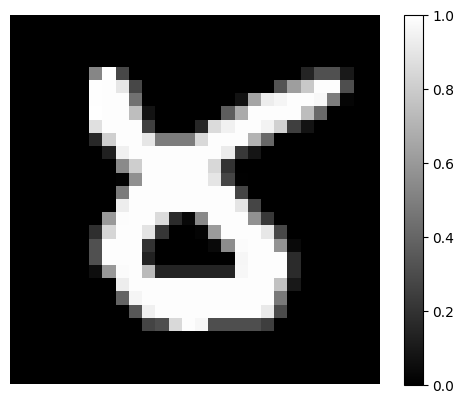

['8']


In [6]:
for images, labels in train_iter:
  print(labels.shape)
  print(images.shape)
  I = images[0].numpy()
  plt.figure(dpi=100)
  plt.imshow(I[0],cmap='gray')
  plt.axis('off')
  plt.colorbar()
  plt.show()
  print(get_mnist_labels([labels[0]]))
  break

## illustration of torchivision transforms
torchvision에서 제공하는 다양한 transform들을 적절히 transform (data augmentation) 에 추가하여 model의 generality를 높이자.
https://pytorch.org/vision/main/transforms.html


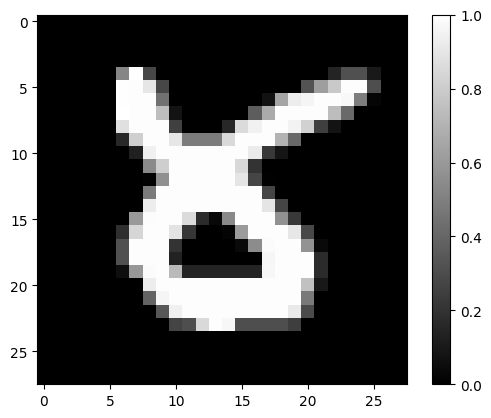

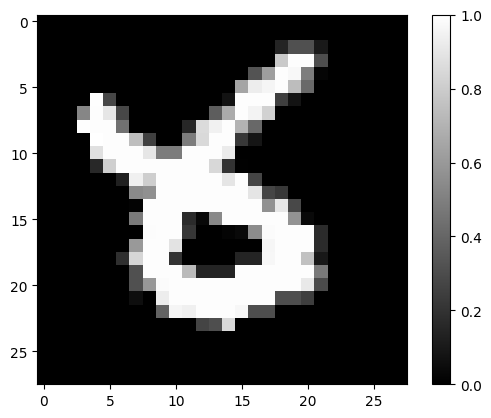

In [7]:
t_imges = v2.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.6, 1.2))(images)
plt.imshow(images[0,0],cmap='gray')
plt.colorbar()
plt.show()
plt.imshow(t_imges[0,0],cmap='gray')
plt.colorbar()
plt.show()

In [8]:
transform = v2.Compose(
    [
        v2.ToTensor(),
        v2.Grayscale(),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input

        v2.RandomRotation(degrees=45),
        v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.6, 1.2)),        # <-- add your transforms
        v2.RandomPerspective(distortion_scale=0.2, p=0.5),
        v2.RandomCrop(size=(28, 28)),
        ]
    )
mnist_train.treansform = transform
print("Traning Transform Updated.")

Traning Transform Updated.


## Network
- 강의노트의 LeNet architecture를 기반으로 CNN model을 정의하기

In [9]:
net = torch.nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=256*3*3, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)

)
net = net.to(device)

- (1, 1, 28, 28) 크기로 정의한 input이 각각의 layer에서 어떤 크기로 변환되는 지를 확인하고 이해하자.

In [10]:
X_dummy = torch.randn(size=(1,1,28,28), dtype=torch.float32).to(device)
print("\nModel Structure:")
for layer in net:
    X_dummy = layer(X_dummy)
    print(layer.__class__.__name__, 'output shape: \t', X_dummy.shape)


Model Structure:
Conv2d output shape: 	 torch.Size([1, 64, 28, 28])
ReLU output shape: 	 torch.Size([1, 64, 28, 28])
MaxPool2d output shape: 	 torch.Size([1, 64, 14, 14])
Conv2d output shape: 	 torch.Size([1, 128, 14, 14])
ReLU output shape: 	 torch.Size([1, 128, 14, 14])
MaxPool2d output shape: 	 torch.Size([1, 128, 7, 7])
Conv2d output shape: 	 torch.Size([1, 256, 7, 7])
ReLU output shape: 	 torch.Size([1, 256, 7, 7])
MaxPool2d output shape: 	 torch.Size([1, 256, 3, 3])
Flatten output shape: 	 torch.Size([1, 2304])
Linear output shape: 	 torch.Size([1, 512])
ReLU output shape: 	 torch.Size([1, 512])
Linear output shape: 	 torch.Size([1, 128])
ReLU output shape: 	 torch.Size([1, 128])
Linear output shape: 	 torch.Size([1, 10])


## Hyperparameters
- learning rate, number of epochs, loss function, algorithm 을 적절하게 정의하기

In [11]:
# setting hyper-parameters
learning_rate = 0.001
num_epochs = 40

# loss function and algorithm
loss = torch.nn.CrossEntropyLoss() # loss
alg = torch.optim.Adam(net.parameters(),lr=learning_rate) # sgd

## Train a Model
- training set/validation set를 활용하여 model을 학습시키기


Start Training...
epoch: 0, train loss: 0.1898, train acc: 0.9383, valid acc: 0.9840
epoch: 2, train loss: 0.0310, train acc: 0.9902, valid acc: 0.9910
epoch: 4, train loss: 0.0192, train acc: 0.9940, valid acc: 0.9910
epoch: 6, train loss: 0.0132, train acc: 0.9957, valid acc: 0.9918
epoch: 8, train loss: 0.0095, train acc: 0.9967, valid acc: 0.9915
epoch: 10, train loss: 0.0091, train acc: 0.9972, valid acc: 0.9910
epoch: 12, train loss: 0.0072, train acc: 0.9977, valid acc: 0.9935
epoch: 14, train loss: 0.0056, train acc: 0.9984, valid acc: 0.9913
epoch: 16, train loss: 0.0049, train acc: 0.9986, valid acc: 0.9928
epoch: 18, train loss: 0.0048, train acc: 0.9986, valid acc: 0.9927
epoch: 20, train loss: 0.0046, train acc: 0.9987, valid acc: 0.9884
epoch: 22, train loss: 0.0056, train acc: 0.9985, valid acc: 0.9935
epoch: 24, train loss: 0.0047, train acc: 0.9986, valid acc: 0.9940
epoch: 26, train loss: 0.0042, train acc: 0.9989, valid acc: 0.9916
epoch: 28, train loss: 0.0033, tra

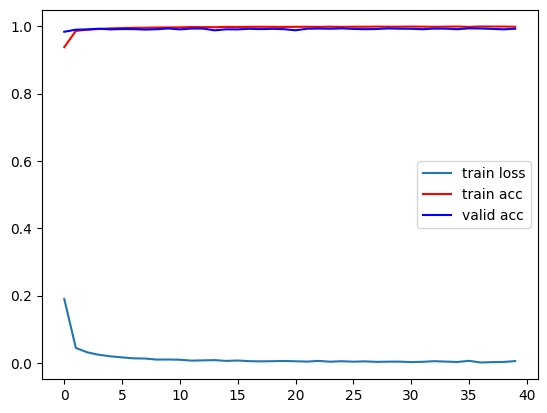

In [12]:
best_acc = 0.0

# Initialize lists to store metrics
loss_train = np.array([])
accs_train = np.array([])
accs_valid = np.array([])

print("\nStart Training...")
for epoch in range(num_epochs):
    i=0
    l_epoch = 0
    correct = 0
    net.train()
    for X,y in train_iter:
        i=i+1
        X,y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat,y)
        l.backward()
        alg.step()
        alg.zero_grad()
        l_epoch += l.cpu().detach().numpy()
        correct += (y_hat.argmax(dim=1)==y).sum().cpu().detach().numpy()

    loss_train = np.append(loss_train,l_epoch/i)
    accs_train = np.append(accs_train,correct/len(mnist_train))

    correct_valid = 0
    net.eval()
    with torch.no_grad():
        for X,y in valid_iter:
            X,y = X.to(device), y.to(device)
            y_hat = net(X)
            correct_valid += (y_hat.argmax(dim=1)==y).sum().cpu().detach().numpy()

    val_acc = correct_valid/len(mnist_valid)
    accs_valid = np.append(accs_valid, val_acc)

    if epoch % 2 == 0:
        print(f'epoch: {epoch}, train loss: {loss_train[-1]:.4f}, train acc: {accs_train[-1]:.4f}, valid acc: {accs_valid[-1]:.4f}')

    # Validation 성능이 좋을 때 모델 저장 (Test에서 최적 성능을 위해)
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(net.state_dict(), 'best_model.pth')

plt.figure(dpi=100)
plt.plot(loss_train,label='train loss')
plt.plot(accs_train,label='train acc',color='red')
plt.plot(accs_valid,label='valid acc',color='blue')
plt.legend()
plt.show()

In [13]:
if os.path.exists('best_model.pth'):
    net.load_state_dict(torch.load('best_model.pth'))
    print("Best model loaded for testing.")

Best model loaded for testing.


In [14]:
torch.save(net.state_dict(),f'my_best_model.pth')

## Results (Validation Set)
- validation set에 대한 결과를 요약해보자.

In [15]:
y_all=[]
y_hat_all=[]
net.eval()
with torch.no_grad():
    for X,y in valid_iter:
      X=X.to(device)
      y_hat = net(X)
      y_hat = y_hat.argmax(dim=1)
      y_all.append(y)
      y_hat_all.append(y_hat)
    y_all = torch.cat(y_all,dim=0)
    y_hat_all = torch.cat(y_hat_all,dim=0)

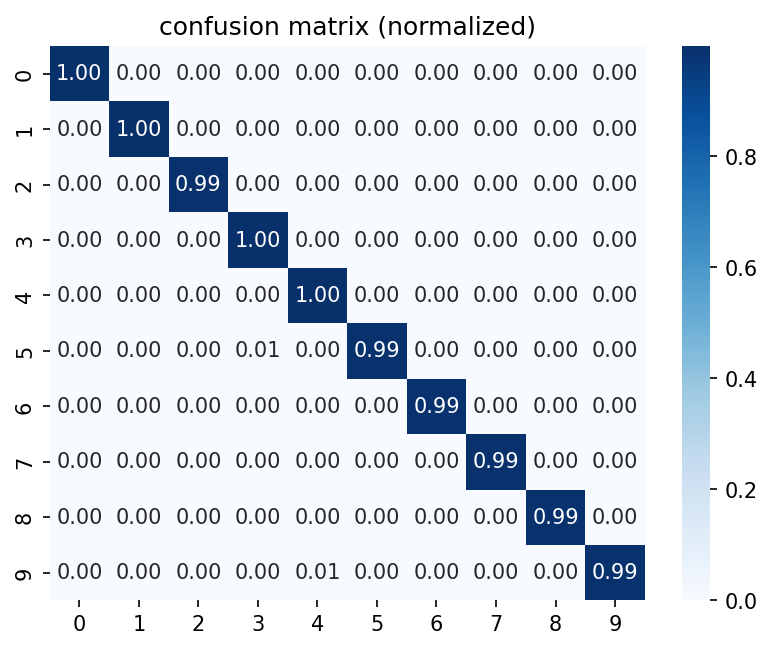

In [16]:
cf = confusion_matrix(y_all.numpy(),y_hat_all.cpu().numpy())
plt.figure(dpi=150)
cf = cf/np.sum(cf,axis=1)
sns.heatmap(cf,annot=True,cmap='Blues',fmt=".2f")
plt.title('confusion matrix (normalized)')
plt.show()

## Results (External Test Set)
- training set / validation set 과는 다른 방법으로 얻어진 데이터에 대해서 모델의 성능을 평가하고, 이에 대한 성능을 개선시킬 수 있는 방법을 고민하자.

In [17]:
!unzip hufs_mnist_2025 -d test

Archive:  hufs_mnist_2025
   creating: test/easy/
  inflating: test/easy/.DS_Store     
  inflating: test/__MACOSX/easy/._.DS_Store  
   creating: test/easy/9/
   creating: test/easy/0/
   creating: test/easy/7/
   creating: test/easy/6/
   creating: test/easy/1/
   creating: test/easy/8/
   creating: test/easy/4/
   creating: test/easy/3/
   creating: test/easy/2/
   creating: test/easy/5/
  inflating: test/easy/9/0_9.png     
  inflating: test/__MACOSX/easy/9/._0_9.png  
  inflating: test/easy/9/2_9.png     
  inflating: test/__MACOSX/easy/9/._2_9.png  
  inflating: test/easy/9/6_9.png     
  inflating: test/__MACOSX/easy/9/._6_9.png  
  inflating: test/easy/9/4_9.png     
  inflating: test/__MACOSX/easy/9/._4_9.png  
  inflating: test/easy/9/3_9.png     
  inflating: test/__MACOSX/easy/9/._3_9.png  
  inflating: test/easy/9/1_9.png     
  inflating: test/__MACOSX/easy/9/._1_9.png  
  inflating: test/easy/9/5_9.png     
  inflating: test/__MACOSX/easy/9/._5_9.png  
  inflating: test/

In [18]:
transform_test = v2.Compose(
    [
        v2.Grayscale(),
        v2.Resize((32,32)),
        v2.CenterCrop(28),
        v2.ToTensor()
    ])

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [19]:
path_test = 'test/hard'

if os.path.exists(path_test):
    data_test = ImageFolder(root=path_test,transform=transform_test)
else:
    print(f"Error: Test path '{path_test}' does not exist.")

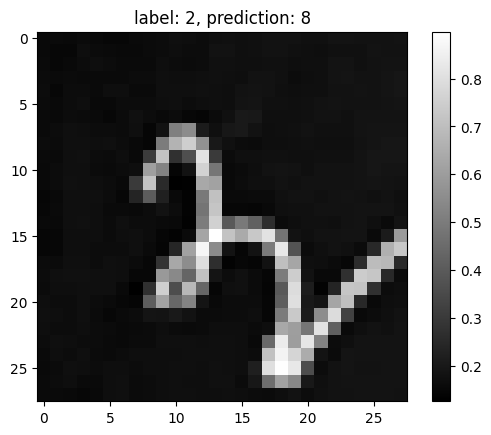

In [20]:
n=32
if 'data_test' in locals() and len(data_test) > 0 and n < len(data_test):
        X = 1-data_test[n][0].unsqueeze(0)
        y = data_test[n][1]
        y_hat = net(X.to(device))
        y_hat = y_hat.argmax(dim=1)
        plt.imshow(X[0,0].cpu(),cmap='gray')
        plt.title(f'label: {y}, prediction: {y_hat.cpu().numpy()[0]}')
        plt.colorbar()
        plt.show()
else:
    print(f"Cannot display example. data_test not loaded or index {n} is out of bounds (length: {len(data_test) if 'data_test' in locals() else 0}).")

In [21]:
num_incorrect = 0
flag_plot = 1

print(f"Evaluating on {path_test}...")

if 'data_test' in locals() and len(data_test) > 0:
    results = np.zeros((2,len(data_test)))
    net.eval()
    with torch.no_grad():
        for n in range(len(data_test)):
            X = 1 - data_test[n][0].unsqueeze(0)
            y = data_test[n][1]
            y_hat = net(X.to(device))
            y_hat = y_hat.argmax(dim=1)

            results[0,n] = y
            results[1,n] = y_hat.cpu().item()

            if y_hat != y:
                num_incorrect+=1
                if num_incorrect % 16 == 0 and flag_plot == 1:
                    # plt.figure(dpi=80)
                    # plt.imshow(X[0].cpu().squeeze(),cmap='gray')
                    # plt.title(f'label: {get_mnist_labels([y])} \n pred: {get_mnist_labels([y_hat])}')
                    # plt.axis('off')
                    # plt.show()
                    pass

    acc = 100*(len(data_test)-num_incorrect)/len(data_test)
    print(f'Accuracy on {path_test}: {acc:.2f}%')
    print(f'Incorrect: {num_incorrect}, Correct: {len(data_test)-num_incorrect}')
else:
    print("data_test is not loaded or is empty. Skipping evaluation.")
    results = np.array([]) # Ensure results is defined even if empty
    acc = 0.0
    num_incorrect = 0

Evaluating on test/hard...
Accuracy on test/hard: 33.57%
Incorrect: 93, Correct: 47


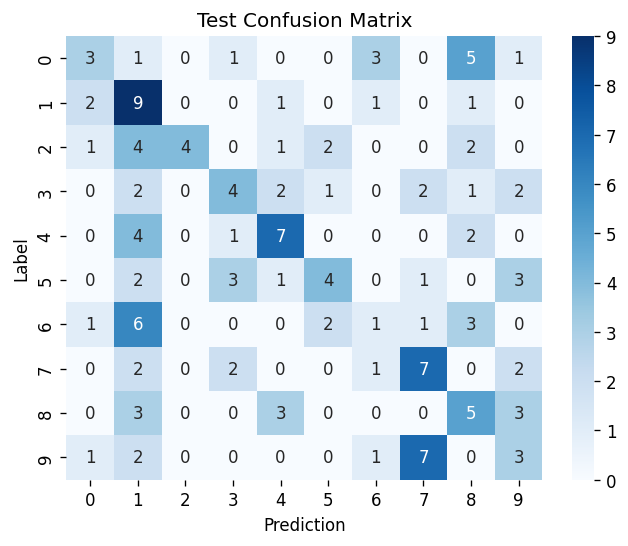

In [22]:
if 'results' in locals() and len(results) > 0:
    cf = confusion_matrix(results[0,:], results[1,:])
    plt.figure(dpi=120)
    sns.heatmap(cf, annot=True, cmap='Blues', fmt='g')
    plt.title('Test Confusion Matrix')
    plt.ylabel('Label')
    plt.xlabel('Prediction')
    plt.show()
else:
    print("Cannot plot confusion matrix. Evaluation results not available.")

## Homework
- transform, model, hyperparameter 등을 적절하게 수정하여 external test set에 대한 accuracy를 높여보자.